Cilj projekta je sljedeci: da li mozemo na osnovu tehnickih karakteristika racunarskog sistema da predvidimo njegovu performansu?

Na osnovu web stranice na kojoj se nalazi dataset, receno je da za svaku kolonu nema nedostajucih vrijednosti, sto bi tehnicki trebalo da olaksa ciscenje podataka.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("data/machine.data", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


Vidimo da ovi podaci dolaze bez headera, te su nazivi kolona 0, 1, 2, ..., 9 umjesto konkretnih naziva, te se to treba promjeniti.

In [3]:
kolone = ["VendorName", "ModelName", "MYCT", "MMIN", "MMAX", "CACH", "CHMIN", "CHMAX", "PRP", "ERP"]

df.columns = kolone
df.head()

,VendorName,ModelName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


Prilikom analize podataka, IDE je oznacio "1 dataset issue", cime je oznacio prisustvo outliera u vise numerickih atributa ("MYCT", "MMIN", "CACH", "CHMIN", "CHMAX"). Nakon dodatne analize, zakljuceno je da ove vrijednosti vjerovatno predstavljaju stvarne ekstremne konfiguracije hardvera, ne gresku pri unosu podataka. Zbog toga ce ovi outlieri ostati i njihova uloga ce se dodatno analizirati kroz performanse modela.

In [4]:
print("Dimenzije: ", df.shape)
print()
print(df.info())
print()
print(df.describe(include="all"))

Dimenzije:  (209, 10)

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   VendorName  209 non-null    str  
 1   ModelName   209 non-null    str  
 2   MYCT        209 non-null    int64
 3   MMIN        209 non-null    int64
 4   MMAX        209 non-null    int64
 5   CACH        209 non-null    int64
 6   CHMIN       209 non-null    int64
 7   CHMAX       209 non-null    int64
 8   PRP         209 non-null    int64
 9   ERP         209 non-null    int64
dtypes: int64(8), str(2)
memory usage: 16.5 KB
None

       VendorName ModelName         MYCT          MMIN          MMAX  \
count         209       209   209.000000    209.000000    209.000000   
unique         30       209          NaN           NaN           NaN   
top           ibm     32/60          NaN           NaN           NaN   
freq           32         1          NaN           NaN           NaN   
me

In [5]:
print("Nedostajuce vrijednosti po kolonama:")
print(df.isnull().sum())
print()
print("Broj duplikata: ", df.duplicated().sum())

Nedostajuce vrijednosti po kolonama:
VendorName    0
ModelName     0
MYCT          0
MMIN          0
MMAX          0
CACH          0
CHMIN         0
CHMAX         0
PRP           0
ERP           0
dtype: int64

Broj duplikata:  0


In [6]:
print(df.nunique())

VendorName     30
ModelName     209
MYCT           60
MMIN           25
MMAX           23
CACH           22
CHMIN          15
CHMAX          31
PRP           116
ERP           104
dtype: int64


In [7]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
print("Kategorijalne kolone:")
print(list(categorical_cols))

numerical_cols = df.select_dtypes(include=["number"]).columns
print("\nNumericke kolone:")
print(list(numerical_cols))

Kategorijalne kolone:
['VendorName', 'ModelName']

Numericke kolone:
['MYCT', 'MMIN', 'MMAX', 'CACH', 'CHMIN', 'CHMAX', 'PRP', 'ERP']


Zelimo da uradimo analizu korelacije u odnosu na ciljnu varijablu PRP.

In [8]:
numeric_df = df[numerical_cols]
corr = numeric_df.corr()

print(corr["PRP"].sort_values(ascending=False))

PRP      1.000000
ERP      0.966472
MMAX     0.863004
MMIN     0.794931
CACH     0.662641
CHMIN    0.608903
CHMAX    0.605209
MYCT    -0.307099
Name: PRP, dtype: float64


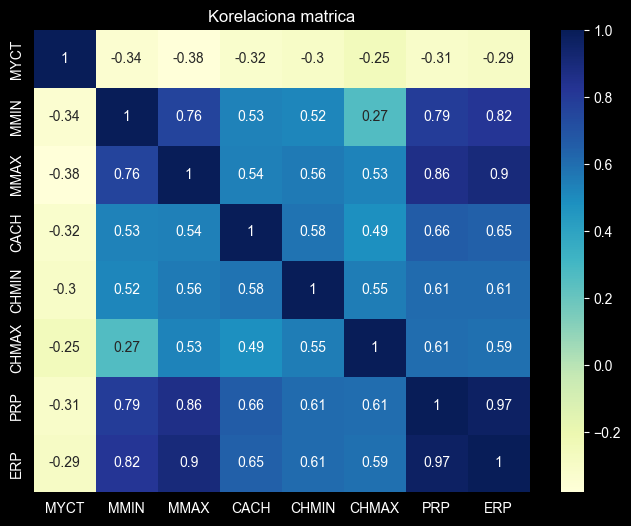

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Korelaciona matrica")
plt.show()

In [9]:
df[numerical_cols].describe()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
count,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000
mean,203.822967,2867.980861,11796.153110,25.205742,4.698565,18.267943,105.622010,99.330144
std,260.262926,3878.742758,11726.564377,40.628722,6.816274,25.997318,160.830733,154.757102
min,17.000000,64.000000,64.000000,0.000000,0.000000,0.000000,6.000000,15.000000
25%,50.000000,768.000000,4000.000000,0.000000,1.000000,5.000000,27.000000,28.000000
50%,110.000000,2000.000000,8000.000000,8.000000,2.000000,8.000000,50.000000,45.000000
75%,225.000000,4000.000000,16000.000000,32.000000,6.000000,24.000000,113.000000,101.000000
max,1500.000000,32000.000000,64000.000000,256.000000,52.000000,176.000000,1150.000000,1238.000000


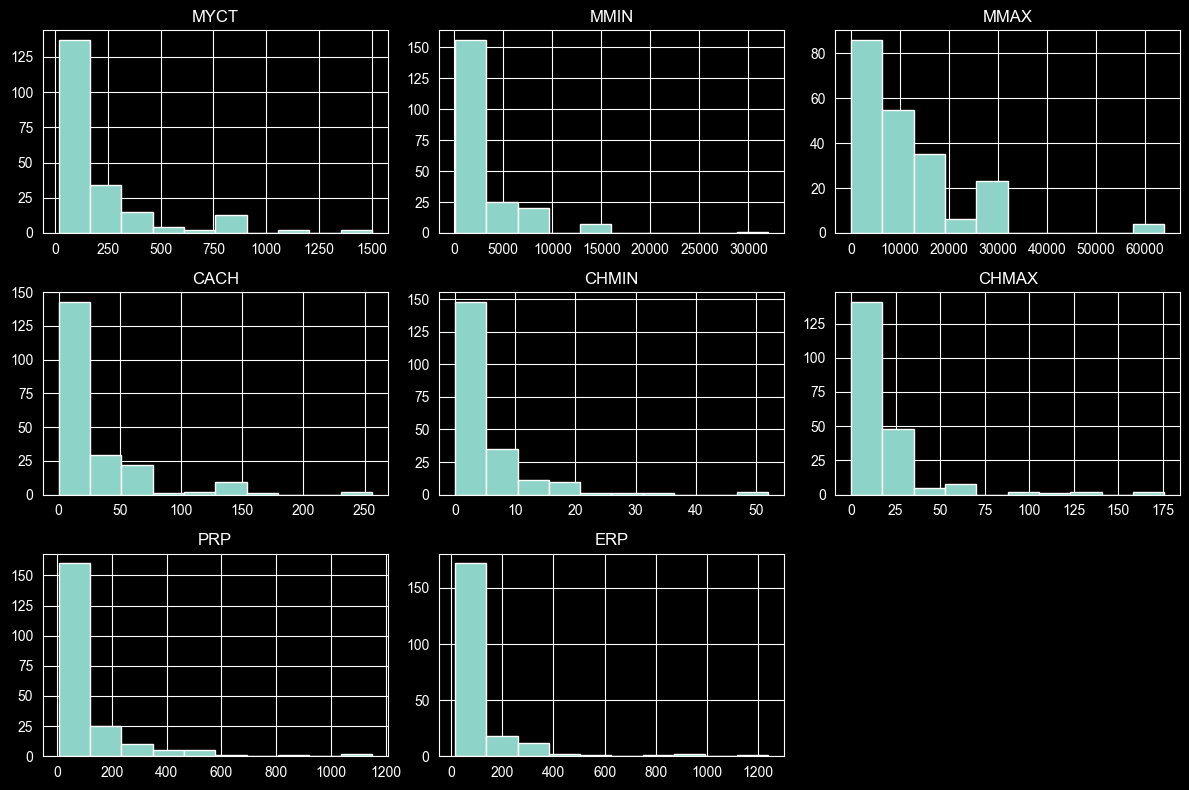

In [10]:
df[numerical_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

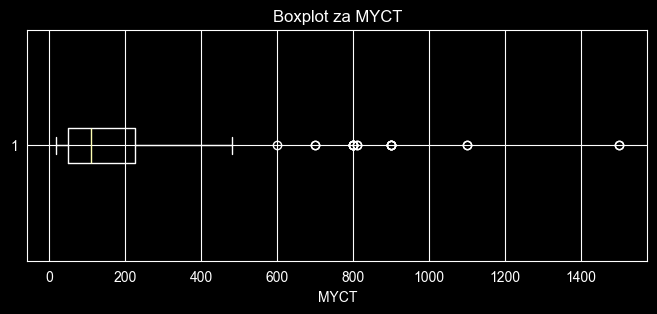

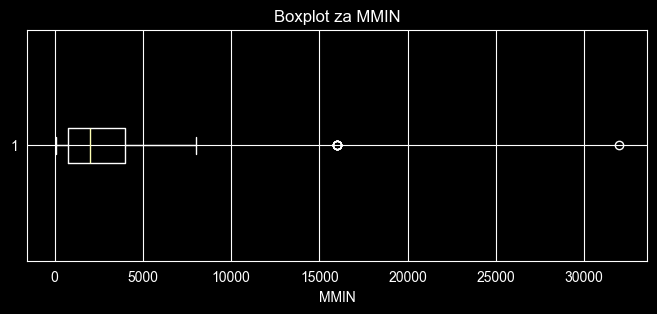

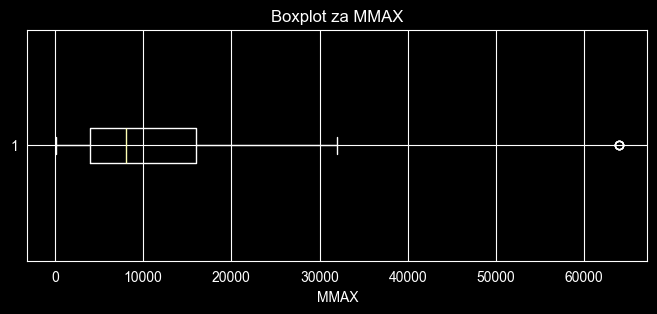

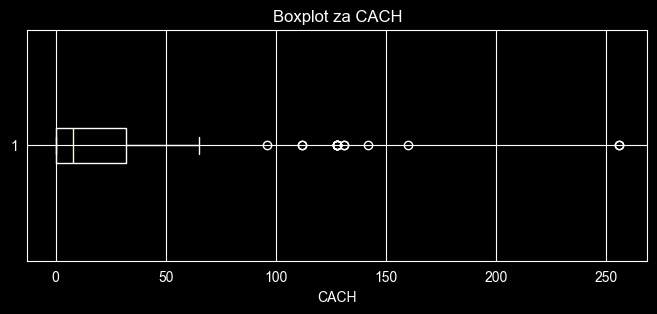

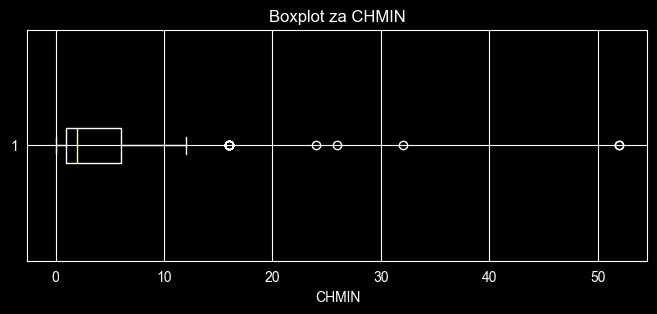

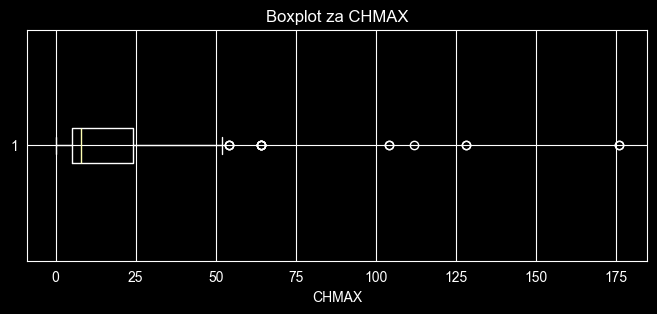

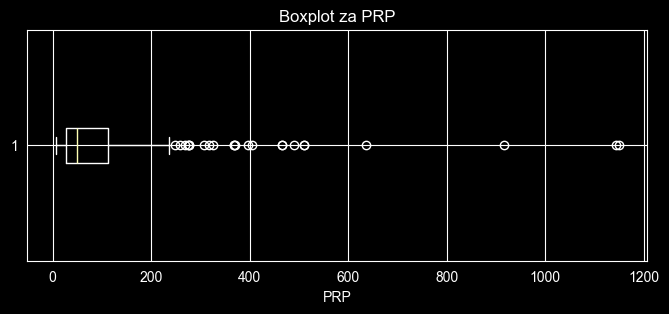

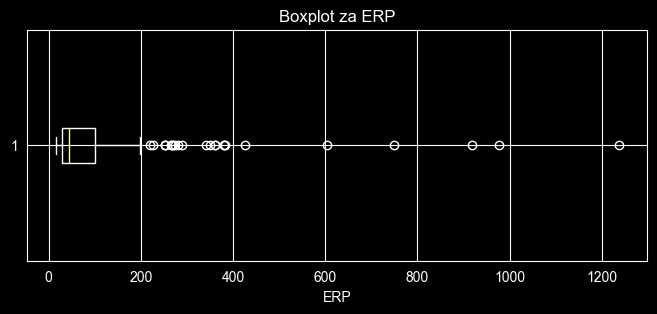

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot za {col}")
    plt.xlabel(col)
    plt.show()

Boxplotovi numerickih atributa pokazuju da dataset sadrzi vise outliera i da su raspodijele vecine atributa desno asimetricne. Vecina vrijednosti je koncentrisana u nizem ili srednjem rasponu, dok se manji broj instanci izdvaja sa znantno vecim vrijednostima. To je ocekivano za kompjuterski hardver, te ne smatram da ima potrebe uklanjati ovakve outliere.

Dakle, dataset sadrzi 209 redova i 10 atributa. Atributi VendorNaame i ModelName su kategorijalni. Atributi MYCT, MMIN, MMAX, CACH, CHMIN, CHMAX, PRP, ERP su numericki. Provjerom je utvrdjeno da dataset nema nedostajucih vrijednosti te je potvrdjeno da nema duplikata. Za treniranje modela ima smisla izbaciti kolone "ModelName" i "ERP" kolone, zato sto je ukljucuivanje ModelName kolone moze dovesti do slabije generalizacije i prevelikog oslanjanja modela na identifikatore umjesto na stvarne hardverske osobine. ERP kolonu izbacujem iz razloga sto je to "estimated relative performance" i smatram da kvari cistocu problema jer model ne uci samo iz hardverskih karakteristika, nego dobija i drugu kolonu koja vec direktno opisuje performansu, sto bi moglo da vodi do previse dobrih rezultata.

In [12]:
X = df.drop(columns=["PRP", "ERP", "ModelName"])
y = df["PRP"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (167, 7)
X_test: (42, 7)
y_train: (167,)
y_test: (42,)


In [14]:
categorical_features = ["VendorName"]
numerical_features = ["MYCT", "MMIN", "MMAX", "CACH", "CHMIN", "CHMAX"]

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

In [17]:
ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [18]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [19]:
y_pred_ridge_train = ridge_model.predict(X_train)
y_pred_ridge_test = ridge_model.predict(X_test)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def ispisi_metrike(y_true, y_pred, naziv):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {naziv} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print()

In [21]:
ispisi_metrike(y_train, y_pred_ridge_train, "Ridge - train")
ispisi_metrike(y_test, y_pred_ridge_test, "Ridge - test")

ispisi_metrike(y_train, y_pred_rf_train, "Random Forest - train")
ispisi_metrike(y_test, y_pred_rf_test, "Random Forest - test")

--- Ridge - train ---
MAE:  30.0085
RMSE: 47.7879
R2:   0.8812

--- Ridge - test ---
MAE:  46.6388
RMSE: 70.6303
R2:   0.9020

--- Random Forest - train ---
MAE:  11.2321
RMSE: 28.5855
R2:   0.9575

--- Random Forest - test ---
MAE:  34.0117
RMSE: 84.3945
R2:   0.8601



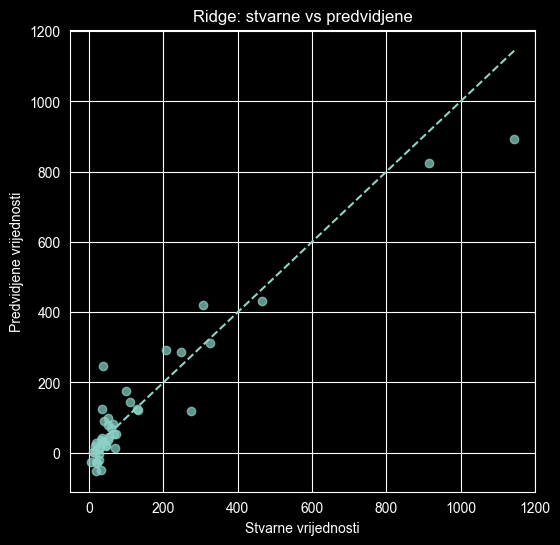

In [22]:


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predvidjene vrijednosti")
plt.title("Ridge: stvarne vs predvidjene")
plt.show()

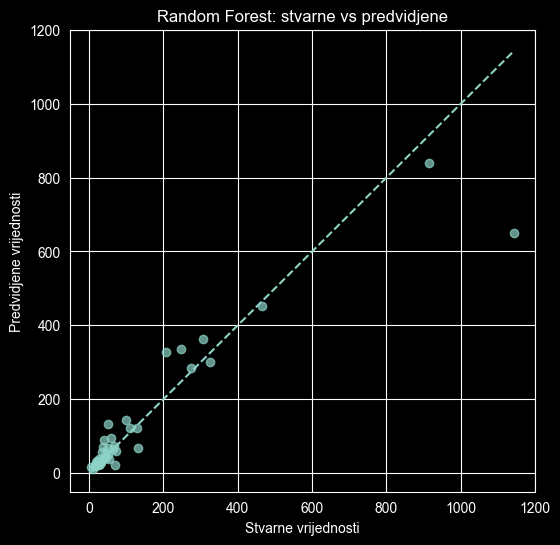

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predvidjene vrijednosti")
plt.title("Random Forest: stvarne vs predvidjene")
plt.show()

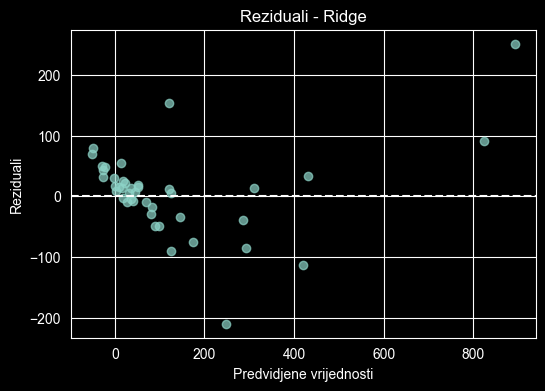

In [24]:
reziduali_ridge = y_test - y_pred_ridge_test

plt.figure(figsize=(6,4))
plt.scatter(y_pred_ridge_test, reziduali_ridge, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predvidjene vrijednosti")
plt.ylabel("Reziduali")
plt.title("Reziduali - Ridge")
plt.show()

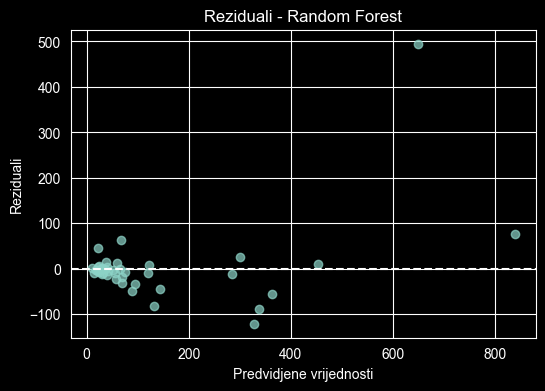

In [25]:
reziduali_rf = y_test - y_pred_rf_test

plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf_test, reziduali_rf, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predvidjene vrijednosti")
plt.ylabel("Reziduali")
plt.title("Reziduali - Random Forest")
plt.show()

In [26]:
from sklearn.inspection import permutation_importance

ridge_importance = permutation_importance(
    ridge_model, X_test, y_test, n_repeats=20, random_state=42
)

rf_importance = permutation_importance(
    rf_model, X_test, y_test, n_repeats=20, random_state=42
)

In [27]:
ridge_imp = pd.Series(ridge_importance.importances_mean, index=X_test.columns).sort_values(ascending=False)
rf_imp = pd.Series(rf_importance.importances_mean, index=X_test.columns).sort_values(ascending=False)

print("Vaznost atributa - Ridge")
print(ridge_imp)
print()

print("Vaznost atributa - Random Forest")
print(rf_imp)

Vaznost atributa - Ridge
MMIN          0.325436
MMAX          0.230587
CHMAX         0.136335
CACH          0.026397
VendorName    0.010870
CHMIN         0.001010
MYCT          0.000635
dtype: float64

Vaznost atributa - Random Forest
MMAX          0.449193
CACH          0.077828
MMIN          0.068413
CHMIN         0.036219
CHMAX         0.031543
MYCT          0.003474
VendorName   -0.003180
dtype: float64


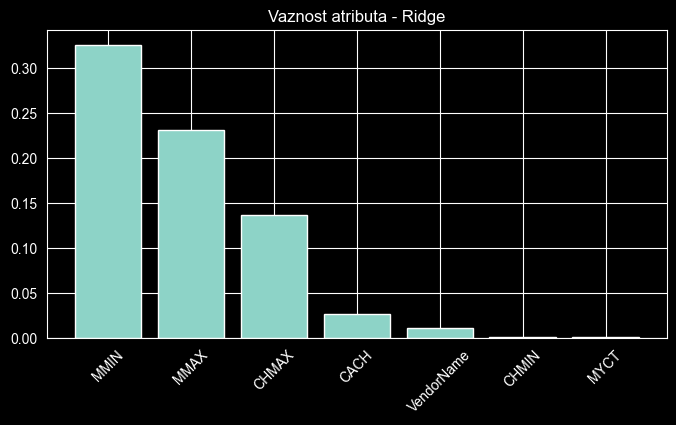

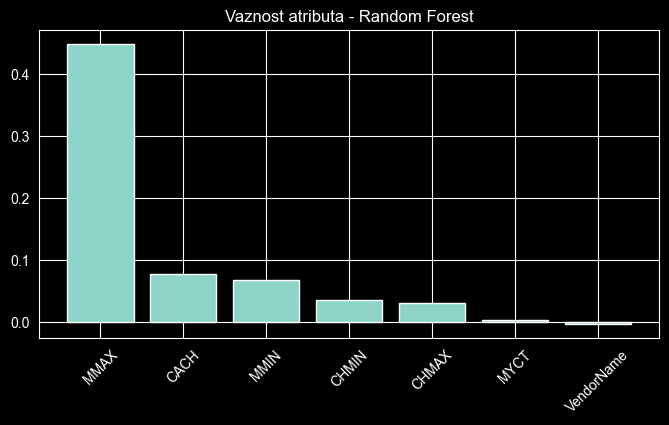

In [28]:
plt.figure(figsize=(8,4))
plt.bar(ridge_imp.index, ridge_imp.values)
plt.xticks(rotation=45)
plt.title("Vaznost atributa - Ridge")
plt.show()

plt.figure(figsize=(8,4))
plt.bar(rf_imp.index, rf_imp.values)
plt.xticks(rotation=45)
plt.title("Vaznost atributa - Random Forest")
plt.show()